# Домашняя работа: NLP Transformer с нуля на PyTorch

В этой домашней работе вы реализуете основные компоненты Transformer для обработки текста:

- character-level токенизацию;
- token embeddings;
- positional embeddings;
- scaled dot-product attention;
- multi-head self-attention;
- causal mask;
- Transformer block;
- decoder-only MiniGPT;
- генерацию текста.

In [5]:
import math
import random
from dataclasses import dataclass
from IPython.display import display, HTML
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)

torch.manual_seed(42)
random.seed(42)

DEVICE: cpu


## 1. Данные

Ниже есть предзаполненный text, на котором можно обучать трансформер, однако, будет гораздо интереснее, если используете свой текст
Модель будет учиться предсказывать следующий символ.

In [6]:
text = """
transformers are neural networks designed to process sequences of data using attention mechanisms.
unlike traditional recurrent neural networks, transformers do not process tokens sequentially.
instead, they look at the entire context at once and learn relationships between tokens.

attention is the key idea behind transformers.
it allows each token to look at every other token in the sequence and decide which ones are important.
this makes transformers very powerful for language modeling and many other tasks.

in a transformer, each token is first converted into an embedding vector.
these embeddings represent the meaning of the tokens in a continuous space.
positional embeddings are added to include information about the order of tokens.

self attention computes how much each token attends to other tokens.
it uses queries, keys, and values.
the attention weights are computed using a softmax over scaled dot products.

multi head attention allows the model to focus on different aspects of the sequence.
each head learns its own attention pattern.
some heads may focus on syntax, while others focus on semantics.

transformers also include feed forward networks after attention layers.
these networks process each token independently.
residual connections help stabilize training and improve gradient flow.

language models based on transformers can generate text.
they learn to predict the next token given previous tokens.
this is called autoregressive generation.

for example, given the prompt "attention is", the model might generate "attention is a mechanism that helps models focus on relevant parts of the input".

training a transformer requires a dataset of text.
the model learns patterns, grammar, and structure from the data.
with enough data and compute, transformers can generate very realistic text.

however, small models trained on small datasets often produce noisy outputs.
this is because they do not have enough data to learn stable patterns.
in such cases, repeating the dataset or simplifying the model can help.

transformers are used in many applications.
they power chatbots, translation systems, and search engines.
they are also used in computer vision and reinforcement learning.

in summary, transformers are flexible and powerful models.
they rely on attention instead of recurrence.
this allows them to scale well and learn complex relationships in data.

attention allows models to focus.
attention helps models understand context.
attention improves performance.
attention is the core idea of transformers.

transformers process tokens in parallel.
transformers learn relationships between tokens.
transformers generate text.
transformers are widely used in modern machine learning.

this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
"""

text = text.lower()
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("Text length:", len(text))
print("Vocab size:", vocab_size)
print("Vocabulary:", "".join(chars))

Text length: 3013
Vocab size: 30
Vocabulary: 
 ",.abcdefghiklmnopqrstuvwxyz


## 2. Кодирование и декодирование текста

### Задание 1

Реализуйте функции:

- `encode(s)` — переводит строку в список индексов;
- `decode(ids)` — переводит список индексов обратно в строку.

In [7]:
def encode(s: str) -> list[int]:
    # TODO: верните список индексов символов через stoi
    return [stoi[c] for c in s]


def decode(ids: list[int]) -> str:
    # TODO: верните строку по списку индексов через itos
    return "".join([itos[i] for i in ids])

In [8]:
sample = "attention"
ids = encode(sample)
assert isinstance(ids, list)
assert all(isinstance(i, int) for i in ids)
assert decode(ids) == sample
print("Encoding/decoding tests passed")

Encoding/decoding tests passed


## 3. Train/validation split

In [9]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 2711
Val tokens: 302


## 4. Создание batch

Для каждого входного токена - нам нужно предсказать следующий токен нашей последовательности.

```text
x = [t, r, a, n]
y = [r, a, n, s]
```


### Реализуйте функцию `get_batch`.

In [10]:
block_size = 32
batch_size = 16

def get_batch(split: str):
    source = train_data if split == "train" else val_data
    ############################################################################
    # TODO:
    # 1. Случайно выберите batch_size стартовых позиций.
    # 2. Для каждой позиции возьмите block_size токенов в x.
    # 3. Для y возьмите те же токены, но сдвинутые на 1 вправо.
    # 4. Перенесите x и y на DEVICE.
    ############################################################################

    ix = torch.randint(len(source) - block_size, size=(batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    
    

In [11]:
x, y = get_batch("train")
assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)
assert x.device.type == torch.device(DEVICE).type
assert y.device.type == torch.device(DEVICE).type
print("Batch tests passed")

Batch tests passed


## 5. Scaled Dot-Product Attention

Attention вычисляет, насколько каждый токен должен смотреть на другие токены.

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

###  Реализуйте функцию `scaled_dot_product_attention`.

In [ ]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    q, k, v: [B, H, T, D]
    mask: [T, T] или None
    """
    ############################################################################
    # TODO:
    # 1. scores = q @ k^T / sqrt(D)
    # 2. если mask не None, запретите смотреть в masked-позиции
    # 3. softmax по последней размерности
    # 4. умножьте attention weights на v
    ############################################################################

    d_k = q.size(-1)
    
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))
        
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, v)
    
    return output, attention_weights

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [13]:
B, H, T, D = 2, 4, 8, 16
q = torch.randn(B, H, T, D)
k = torch.randn(B, H, T, D)
v = torch.randn(B, H, T, D)

out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (B, H, T, D)
assert attn.shape == (B, H, T, T)
assert torch.allclose(attn.sum(dim=-1), torch.ones(B, H, T), atol=1e-5)
print("Scaled attention tests passed")

Scaled attention tests passed


## 6. Causal mask

В NLP модель должна предсказывать следующий токен, опираясь только на уже известные предыдущие токены. Если разрешить ей на будущие позиции, она будет использовать информацию из ответа, что делает обучение некорректным и нереалистичным. Поэтому мы вводим causal mask — матрицу, которая для каждой позиции разрешает учитывать только текущие и предыдущие токены, но запрещает доступ к будущим.


### Реализуйте `make_causal_mask`.

In [14]:
def make_causal_mask(seq_len: int, device=None):
    # TODO: верните bool-матрицу [seq_len, seq_len], где True = можно смотреть
    
    return torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device))

In [15]:
mask = make_causal_mask(4)
expected = torch.tensor([
    [1, 0, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 1],
], dtype=torch.bool)
assert mask.shape == (4, 4)
assert torch.equal(mask.cpu(), expected)
print("Causal mask tests passed")

Causal mask tests passed


## 7. Multi-Head Self-Attention

Реализуйте класс `MultiHeadSelfAttention`.

Класс `MultiHeadSelfAttention` сначала проецирует входные эмбеддинги в три матрицы — запросы (Q), ключи (K) и значения (V) — с помощью линейного слоя, после чего разбивает их на несколько “голов”. Для каждой головы независимо считается scaled dot-product attention, затем результаты объединяются обратно в единое представление и проходят через финальную линейную проекцию, позволяя модели одновременно учитывать разные типы зависимостей между токенами.

In [18]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attention = None

    def forward(self, x, mask=None):
        B, T, C = x.shape
        ############################################################################
        # TODO:
        # 1. получите qkv
        # 2. разделите q, k, v
        # 3. приведите к форме [B, H, T, D]
        # 4. вызовите scaled_dot_product_attention
        # 5. объедините головы обратно в [B, T, C]
        # 6. примените proj и dropout
        # 7. сохраните attention в self.last_attention
        ############################################################################

        q, k, v = self.qkv(x).split(self.embed_dim, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn_output, attn_weights = scaled_dot_product_attention(q, k, v, mask=mask)

        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, C)

        out = self.dropout(self.proj(attn_output))

        self.last_attention = attn_weights

        return out

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

In [19]:
mha = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = mha(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
assert mha.last_attention is not None
assert mha.last_attention.shape == (2, 4, 10, 10)
print("Multi-head attention tests passed")

Multi-head attention tests passed


## 8. Feed Forward Network

### Реализуйте `FeedForward`.

In [20]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        ############################################################################
        # TODO: nn.Sequential: Linear -> GELU -> Linear -> Dropout
        ############################################################################
        
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(p=dropout)
        )
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, x):
        return self.net(x)

In [21]:
ff = FeedForward(embed_dim=64, hidden_dim=256)
x_demo = torch.randn(2, 10, 64)
out = ff(x_demo)
assert out.shape == (2, 10, 64)
print("FeedForward tests passed")

FeedForward tests passed


## 9. Transformer Block

Используем Pre-LN вариант:

```python
x = x + attention(layer_norm(x))
x = x + mlp(layer_norm(x))
```

### Реализуйте `TransformerBlock`.


In [22]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: int = 4, dropout: float = 0.1):
        super().__init__()
        ############################################################################
        # TODO: ln1, attn, ln2, ff
        ############################################################################
        
        hidden_dim = embed_dim * mlp_ratio
        
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout)
        
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim=embed_dim, hidden_dim=hidden_dim, dropout=dropout)

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.ff(self.ln2(x))
        return x

In [23]:
block = TransformerBlock(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = block(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
print("TransformerBlock tests passed")

TransformerBlock tests passed


## 10. Конфигурация модели

In [24]:
@dataclass
class TransformerConfig:
    vocab_size: int
    block_size: int = 16
    embed_dim: int = 64
    num_heads: int = 4
    depth: int = 2
    dropout: float = 0.1

## 11. MiniGPT / Decoder-only Transformer

### Реализуйте класс `MiniGPT`.

In [25]:
class MiniGPT(nn.Module):
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config
        self.token_embedding = nn.Embedding(config.vocab_size, config.embed_dim)
        self.position_embedding = nn.Embedding(config.block_size, config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=config.embed_dim,
                num_heads=config.num_heads,
                mlp_ratio=4,
                dropout=config.dropout,
            )
            for _ in range(config.depth)
        ])

        self.ln_f = nn.LayerNorm(config.embed_dim)
        self.lm_head = nn.Linear(config.embed_dim, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size
        ############################################################################
        # TODO:
        # 1. token embeddings
        # 2. positional embeddings
        # 3. сложить embeddings
        # 4. causal mask
        # 5. Transformer blocks
        # 6. logits
        # 7. loss, если targets is not None
        ############################################################################

        tok_embs = self.token_embedding(idx)
        positions = torch.arange(T, dtype=torch.long, device=idx.device)
        pos_embs = self.position_embedding(positions)
        
        x = self.dropout(tok_embs + pos_embs)
        
        causal_mask = make_causal_mask(T, device=idx.device)
        
        for block in self.blocks:
            x = block(x, mask=causal_mask)
        
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        loss = None
        if targets is not None:
            logits_reshaped = logits.reshape(B * T, -1)
            targets_reshaped = targets.reshape(-1)
            loss = F.cross_entropy(logits_reshaped, targets_reshaped)
            
        return logits, loss

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
        """
        idx: [B, T]
        """
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx

In [26]:
config = TransformerConfig(vocab_size=vocab_size, block_size=32, embed_dim=64, num_heads=4, depth=2, dropout=0.1)
model = MiniGPT(config).to(DEVICE)
x, y = get_batch("train")
logits, loss = model(x, y)
assert logits.shape == (batch_size, block_size, vocab_size)
assert loss is not None and loss.ndim == 0
start = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
generated = model.generate(start, max_new_tokens=10)
assert generated.shape == (1, 11)
print("MiniGPT tests passed")
print("Parameters:", sum(p.numel() for p in model.parameters()))

MiniGPT tests passed
Parameters: 106014


## 12. Оценка loss

### Реализуйте `estimate_loss`.

In [27]:
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 20):
    model.eval()
    results = {}
    ############################################################################
    # TODO: посчитайте средний loss для train и val
    ############################################################################
    
    for split in ["train", "val"]:
        split_losses = torch.zeros(eval_iters)
        for i in range(eval_iters):
            x_batch, y_batch = get_batch(split)
            _, loss = model(x_batch, y_batch)
            split_losses[i] = loss.item()
            
        results[split] = split_losses.mean().item()
        
    model.train()
    return results

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [28]:
losses = estimate_loss(model, eval_iters=2)
assert "train" in losses and "val" in losses
assert isinstance(losses["train"], float)
assert isinstance(losses["val"], float)
print("Estimate loss tests passed:", losses)

Estimate loss tests passed: {'train': 3.5064687728881836, 'val': 3.489654302597046}


## 13. Training loop

Поставьте `RUN_TRAINING=True`, когда все TODO реализованы.

In [29]:

config = TransformerConfig(vocab_size=vocab_size, block_size=32, embed_dim=128, num_heads=4, depth=4, dropout=0.1)
model = MiniGPT(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

max_iters = 1000
eval_interval = 100
loss_history = []

for step in range(max_iters):
    if step % eval_interval == 0:
        losses = estimate_loss(model, eval_iters=20)
        print(f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
print("Training finished")


step 0: train loss 3.5249, val loss 3.5189
step 100: train loss 2.2602, val loss 2.1324
step 200: train loss 2.1005, val loss 2.0300
step 300: train loss 1.8964, val loss 1.8352
step 400: train loss 1.6241, val loss 1.6616
step 500: train loss 1.3963, val loss 1.5515
step 600: train loss 1.1663, val loss 1.5252
step 700: train loss 0.9831, val loss 1.5090
step 800: train loss 0.8364, val loss 1.5398
step 900: train loss 0.6971, val loss 1.5289
Training finished


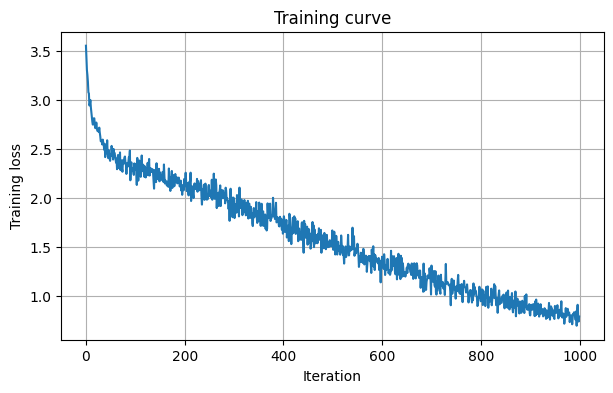

In [30]:
if loss_history:
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Training loss")
    plt.title("Training curve")
    plt.grid(True)
    plt.show()

## 14. Генерация текста

In [31]:

model.eval()
prompt = "attention"
idx = torch.tensor([encode(prompt)], dtype=torch.long, device=DEVICE)
out = model.generate(idx, max_new_tokens=300, temperature=0.8)
print(decode(out[0].tolist()))


attention improves patterns.
in sucase weques, and computes products.
attention is a the corce nough power tokens.
this is a the datasetsets of the keps meary of the tokens in a token in syntiall learn counting.
allows attention is the model models to fot on spaces.

inulhars casets on sequerial and larnigur


## 15. Визуализация attention

In [32]:
def visualize_attention(model: MiniGPT, input_text: str, layer_id: int = -1, head_id: int = 0):
    model.eval()

    idx = torch.tensor([encode(input_text)], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = model(idx)

    block = model.blocks[layer_id]
    attn = block.attn.last_attention

    assert attn is not None
    assert 0 <= head_id < attn.shape[1]

    attn_map = attn[0, head_id].detach().cpu()  # [T, T]
    tokens = list(input_text)

    plt.figure(figsize=(7, 6))
    plt.imshow(attn_map, cmap="viridis")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"Attention heatmap: layer={layer_id}, head={head_id}")

    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)

    plt.xlabel("Key / previous tokens")
    plt.ylabel("Query / current token")
    plt.tight_layout()
    plt.show()

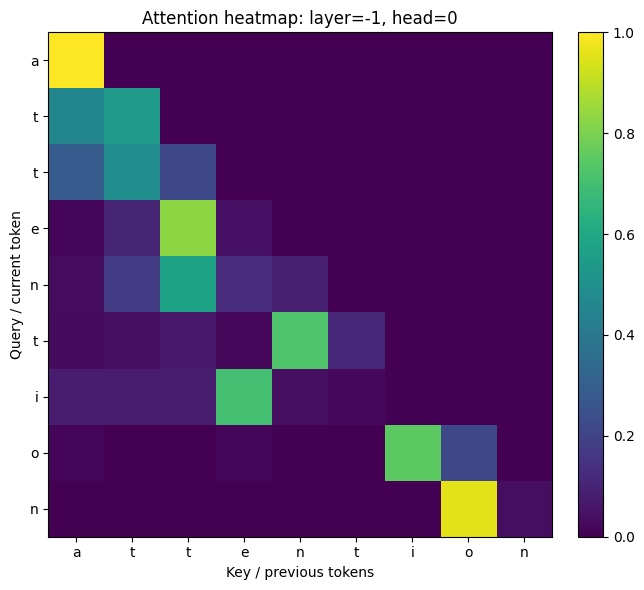

In [33]:

visualize_attention(model, "attention", layer_id=-1, head_id=0)

## 16. Теоретическая часть

1. Почему attention делят на `sqrt(d_k)`?
2. Чем decoder-only Transformer отличается от encoder-only Transformer?
3. Что будет, если убрать residual connections?
4. Почему маленькая модель на маленьком тексте быстро переобучается?


1. Деление на sqrt(d_k) нужно, чтобы значения attention не становились слишком большими, иначе softmax будет выдавать околонулевые значения кроме одного и градиенты могут затухать

2. decoder-only видит только предыдущие токены без будущих слов и по ним генерирует следующий токен
encoder-only видит весь текст целиком, включая будущие слова

3. Без residual connections слои перестанут нормально передавать информацию, а градиенты начнут затухать

4. Маленькая модель на маленьком датасете быстро запоминает текст вместо изучения закономерностей

## Оценка модели

Perplexity — информативная метрика для языковых моделей, которая отражает уверенность модели в предсказаниях следующего токена. В отличие от accuracy, которая учитывает только точные совпадения, perplexity использует вероятности и "наказывает" модель даже за “почти правильные” ответы, если она не уверена. Кроме того, perplexity имеет понятную интерпретацию: это среднее “количество вариантов”, из которых модель как бы выбирает следующий токен — чем меньше, тем лучше модель понимает текст.

Значения perplexity можно оценить так:
- PPL примерно 1–2 - отлично (почти запомнила)
- PPL примерно 10–50 - нормально
- PPL > 100 - плохо

In [35]:
def perplexity(loss_value):
    return math.exp(loss_value)

In [36]:
@torch.no_grad()
def evaluate_loss_on_text_sampled(model, text, num_batches=50, batch_size=64):
    model.eval()

    data = torch.tensor(encode(text), dtype=torch.long).to(DEVICE)

    max_start = len(data) - block_size - 1
    if max_start <= 0:
        raise ValueError(
            f"Text is too short: len={len(data)}, block_size={block_size}"
        )

    losses = []

    for _ in range(num_batches):
        ix = torch.randint(0, max_start, (batch_size,), device=DEVICE)

        x = torch.stack([data[i:i + block_size] for i in ix])
        y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])

        _, loss = model(x, y)
        losses.append(loss.item())

    return sum(losses) / len(losses)

loss = evaluate_loss_on_text_sampled(model, text)
ppl = perplexity(loss)

In [37]:

display(HTML(f"<h1>Оценка Вашей модели: {ppl:.2f}</h1>"))